## Lab Session 3

## Basics working with data

In this notebook we will practice the following "data science" steps:
1. Handeling of missing values.
2. Visualising the data.
3. Learning insights from you data.

We will not give a complete course in Python, but will expect you to do some self-study. 
The idea is that you will fill in the answers in this notebook, save it, and upload to to Black Board before the deadline.

In [11]:
import pandas as pd #importing the pandas library
import seaborn as sns #importing seaborn
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

Note "%matplotlib inline". This line tells the notebook to put the plot inside the notebook. This is not used in Python scripts which are executed like "normal programs".

<div class="alert alert-block alert-warning">

## Task 1: Seaborn

To illustrate how seaborn plotting works run the following example. Seaborn accesses the columns of a pandas dataframe directly. You only have to specifiy the dataframe and the name of the columns for the plotting axes.

</div>

<Axes: xlabel='index', ylabel='number'>

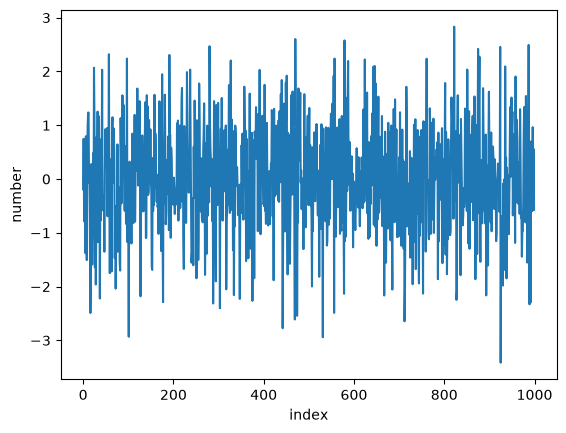

In [12]:
#Generate a random vector sampling from a normal distribution with mean=0, sig=1
#and convert in into a pandas dataframe object
#we call reset_index() on the new dataframe. This adds a new column to our dataframe, 
#which can then be accessed by seaborn to plot the data
df_random = pd.DataFrame(data=np.random.normal(size=1000),columns = ["number"]).reset_index()

#We polot the data with seaborn, specifing x and y axis and the datasource (df_random)
sns.lineplot(x="index",y="number",data=df_random)

<div class="alert alert-block alert-warning">

## Task 2: Loading the data

2.1. Load the titanic dataset ("titanic.csv") contained in this exercise using pandas functions 
into the variable <i>df_titanic</i>.

2.2. The dataset contains missing values. Use the isnull() and sum() method of <i>df_titanic</i> to show which columns have the most missing values.
</div>


In [13]:
#Task 2.1
df_titanic = pd.read_csv("titanic.csv")
df_titanic.head()

,Unnamed: 0,Age,Cabin,Embarked,Fare,Name,Parch,PassengerId,Pclass,Sex,SibSp,Survived,Ticket
0,0,22.0,NaN,S,7.2500,"Braund, Mr. Owen Harris",0,1,3,male,1,0.0,A/5 21171
1,1,38.0,C85,C,71.2833,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,2,1,female,1,1.0,PC 17599
2,2,26.0,NaN,S,7.9250,"Heikkinen, Miss. Laina",0,3,3,female,0,1.0,STON/O2. 3101282
3,3,35.0,C123,S,53.1000,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,4,1,female,1,1.0,113803
4,4,35.0,NaN,S,8.0500,"Allen, Mr. William Henry",0,5,3,male,0,0.0,373450


In [14]:
#Task 2.2

df_titanic.isnull().sum()

Unnamed: 0        0
Age             263
Cabin          1014
Embarked          2
Fare              1
Name              0
Parch             0
PassengerId       0
Pclass            0
Sex               0
SibSp             0
Survived        418
Ticket            0
dtype: int64

<div class="alert alert-block alert-warning">

## Task 3: Imputing missing values

Three columns have missing values the most: "Age", "Cabin", and "Survived". 
Cabin misses approx. 80% of its values and is not the right candidate for simple imputation approaches.
We focus on the <strong>Age</strong> column, where about 20% of the entries are missing.

3.1. Use the <strong>fillna()</strong> method and only impute the <strong>Age</strong> column with the mean age value(see <strong>mean()</strong> method). Save the result in a new column called "Age_imp_mean".

3.2. Use the method parameter <b>method="ffill"</b> of the <b>fillna()</b> method to fill missing values with a preceding value. Save the result in a new collumn called "Age_imp_ffill".

3.3 Plot histogramms of both columns using seaborn, with parameters <b>hist=True</b>, <b>kde=False</b> and <b>bins=40</b>. Also plot the <strong>Age</strong> column for comparision (use the dropna() to avoid errors). Put everything into one plot.

3.4 Plot boxplots of all three columns. Here we want to use seaborn's boxplot function with the <strong>data=</strong> parameter.

3.5 Explain what the different parts of the boxplot are:
* Horizontal line whitin the colored area
* Width of the colored area
* With of the Area between the two horizontal lines below and above the colored area ("whiskers")
* Dots or points above and below the wiskers.

3.6 Explain what effect each imputation strategy had:
* Using the histogramm - When we analyse the survival of patients with a specific age, lets say the ages close to the mean. Can we trust that the mean survial rate is accurate for that age bracket? Why or why not?
    
* Using the boxplot - When we want to find outliers in regards to age, what method would yield more passengers? Why is that the case? (hint: How is an outlier defined in (seaborn) box-plots?).
</div>


In [ ]:
#Task 3.1: Use the <strong>fillna()</strong> method and only impute the <strong>Age</strong>
#column with the mean age value(see <strong>mean()</strong> method). Save the result in a new 
# column called "Age_imp_mean".

#Your code
mean_age = df_titanic["Age"].mean()
df_titanic["Age_imp_mean"] = df_titanic["Age"].fillna(mean_age)
# df_titanic.head(20)

In [ ]:
#Task 3.2: Use the method parameter <b>method="ffill"</b> of the <b>fillna()</b> method to 
# fill missing values with a preceding value. Save the result in a new collumn called 
# "Age_imp_ffill".

#Your code
df_titanic["Age_imp_ffill"] = df_titanic["Age"].ffill()
# df_titanic.head(20)


<Axes: xlabel='Age_imp_mean', ylabel='Count'>

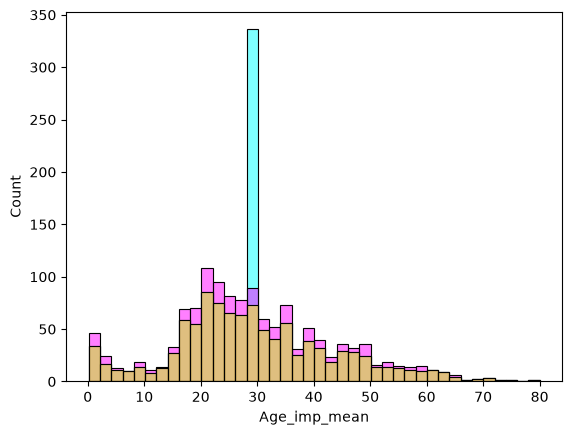

In [ ]:
#Task 3.3 Plot histogramms of both columns using seaborn, with parameters <b>hist=True</b>, 
# <b>kde=False</b> and <b>bins=40</b>. Also plot the <strong>Age</strong> column for comparision 
# (use the dropna() to avoid errors). Put everything into one plot.

plt.figure(1)
#Your code
sns.histplot(df_titanic["Age_imp_mean"].dropna(), bins=40, kde=False, color='cyan', label='Age_imp_mean', alpha=0.5)
sns.histplot(df_titanic["Age_imp_ffill"].dropna(), bins=40, kde=False, color='magenta', label='Age_imp_ffill', alpha=0.5)
sns.histplot(df_titanic["Age"].dropna(), bins=40, kde=False, color='yellow', label='Age', alpha=0.5)


<Axes: >

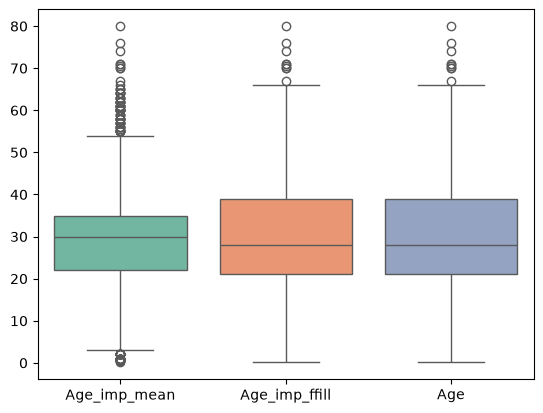

In [ ]:
#Task 3.4 Plot boxplots of all three columns. Here we want to use seaborn's boxplot function 
# with the <strong>data=</strong> parameter.

plt.figure(2)
#Your code
sns.boxplot(data=df_titanic[["Age_imp_mean", "Age_imp_ffill", "Age"]], palette="Set2")

In [ ]:
#Task 3.5 Explain what the different parts of the boxplot are:
# * Horizontal line whitin the colored area
# * Width of the colored area
# * With of the Area between the two horizontal lines below and above the colored area ("whiskers")
# * Dots or points above and below the wiskers.

"""
Write your answer here.
Horizontal line indictaes the median age in the sample data 
Width of the colored area indicates the the range $Q_1$ to $Q_3$ (Interquartile Range (IQR)) 
The Whiskers indicate the range between $Q_1 - 1.5 \times IQR$ and $Q_3 + 1.5 \times IQR$ 
The dots above/below the whiskers indicate outliers in the data, essentially unusual observations
compared to the rest of the data.
"""

'\nWrite your answer here. \n\nHorizontal line indictaes the median age in the sample data \n\nWidth of the colored area indicates the the range $Q_1$ to $Q_3$ (Interquartile Range (IQR)) \\\nThe Whiskers indicate the range between $Q_1 - 1.5 \times IQR$ and $Q_3 + 1.5 \times IQR$ \\\nThe dots above/below the whiskers indicate outliers in the data, essentially unusual observations\\\ncompared to the rest of the data.\n'

In [48]:
#Task 3.6 Explain what effect each imputation strategy had:
# * Using the histogramm - When we analyse the survival of patients with a specific age, 
# lets say the ages close to the mean. Can we trust that the mean survial rate is accurate for 
# that age bracket? Why or why not?
    
"""
Write your answer here.
Removing the missing values reduces the sample size and can lead to biased estimates.
Imputing missing values with the mean age leads to an overestimation of the median age and gives a false variance.
Imputing missing values with the previous value leads to a more accurate representation of the data far better than replacing it
with the mean. However, it does slightly underestimate the variance of the data, as it pressumes that the previous value is a 
good representation of the missing value, which may not always be the case.

No we can't trust that the surviving rate is accurate for that age bracket, as the imputation strategies used to fill in 
the missing values can introduce bias and affect the overall distribution of the data. Specifically, using the mean age to 
impute missing values can lead to an overestimation of the median age and a false variance, while using the previous value to 
impute missing values can lead to an underestimation of the variance. Therefore, it is important to carefully consider the 
imputation strategy used and its potential impact on the analysis.

"""

"\nWrite your answer here.\nRemoving the missing values reduces the sample size and can lead to biased estimates.\nImputing missing values with the mean age leads to an overestimation of the median age and gives a false variance.\nImputing missing values with the previous value leads to a more accurate representation of the data far better than replacing it\nwith the mean. However, it does slightly underestimate the variance of the data, as it pressumes that the previous value is a \ngood representation of the missing value, which may not always be the case.\n\nNo we can't trust that the surviving rate is accurate for that age bracket, as the imputation strategies used to fill in \nthe missing values can introduce bias and affect the overall distribution of the data. Specifically, using the mean age to \nimpute missing values can lead to an overestimation of the median age and a false variance, while using the previous value to \nimpute missing values can lead to an underestimation of 

<div class="alert alert-block alert-warning">

## Task 4

(from https://www.kaggle.com/c/titanic) The sinking of the RMS Titanic is one of the most infamous shipwrecks in history.  On April 15, 1912, during her maiden voyage, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 passengers and crew. This tragedy shocked the international community and led to better safety regulations for ships. One of the reasons that the shipwreck led to such loss of life was that there were not enough lifeboats for the passengers and crew. Although there was some element of luck involved in surviving the sinking, some groups of people were more likely to survive than others... let's see if we can figure out which ones.


First lets explore the data a bit further:
* 4.1 Use the <strong>relplot()</strong> function in pandas to make a scatterplot of "Fare" vs. "Age", colored by "Survived" (hue parameter) and split by "Sex"(col parameter). Is Age correlated with Fare? Do passengers who pay more have a better chance of survival? Is that always true?

* 4.2 Plot "Pclass" vs. "Fare" colored by Sex using a boxplot. Anything unusual besides higher fares for higher classes?

* 4.3 How is the survival rate of passengers(colored by "Sex") in the different classes ("Pclass")? Make a barplot.

</div>

'\nWrite your answer to the question here.\n\nThe strongest correlation we see is that off being female and surviving compared to their male counterparts. For Females, there is also\na strong correlation between fare price and survival, with higher fares correlating with higher survival rates. Age does not seem to matter\nwhen counting survival rates for women. \n\nFor males age does seem to matter for those under the age of 12-15, after that age does not seem to matter for survival rates. For males,\nthere doesnt seem to be a correlation between fare price and survival rate, except for the outliers who paid the highest fare price of \nabove 500. Although sample size is small.\n\n'

<Figure size 640x480 with 0 Axes>

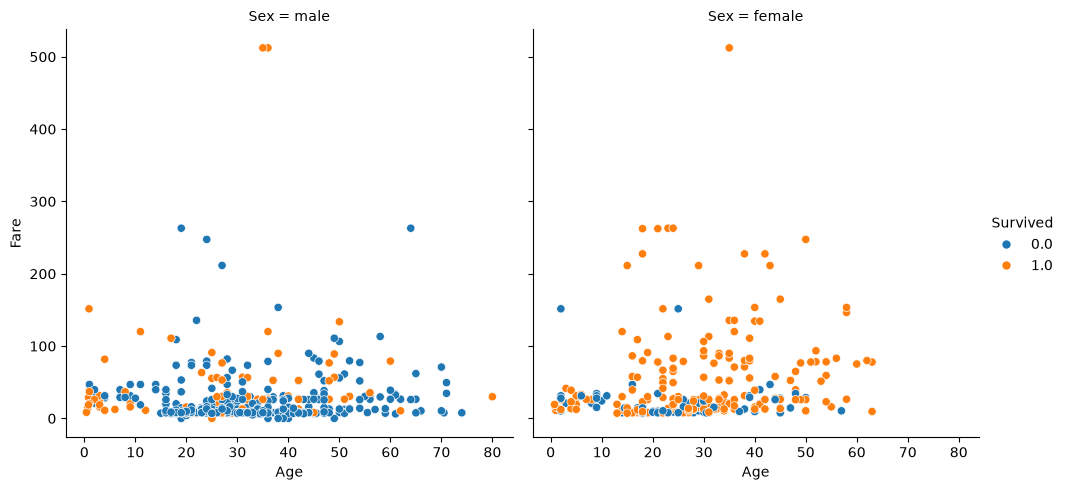

In [51]:
#Task 4.1 Use the <strong>relplot()</strong> function in pandas to make a scatterplot of "Fare" vs. "Age", colored by "Survived" 
# (hue parameter) and split by "Sex"(col parameter). Is Age correlated with Fare? Do passengers who pay more have a better chance 
# of survival? Is that always true?
plt.figure(3)
#Your code
sns.relplot(x="Age", y="Fare", hue="Survived", col="Sex", data=df_titanic, kind="scatter")


"""
Write your answer to the question here.

The strongest correlation we see is that off being female and surviving compared to their male counterparts. For Females, there is also
a strong correlation between fare price and survival, with higher fares correlating with higher survival rates. Age does not seem to matter
when counting survival rates for women. 

For males age does seem to matter for those under the age of 12-15, after that age does not seem to matter for survival rates. For males,
there doesnt seem to be a correlation between fare price and survival rate, except for the outliers who paid the highest fare price of 
above 500. Although sample size is small.

"""

'\nWrite your answer to the question here.\n\nIn general we see more outliers for males in all classes when it comes to fare prices. This could be due to a lot of sociatal factors,\nThe female population seem to be more uniform in their fare prices with way less outliers for each class.\n\n'

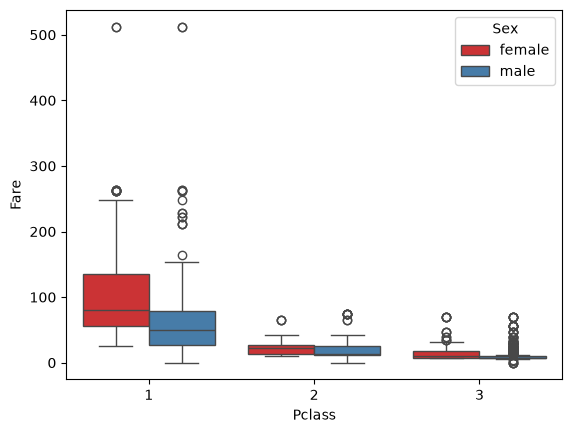

In [ ]:
#Task 4.2 Plot "Pclass" vs. "Fare" colored by Sex using a boxplot. Anything unusual besides higher fares for higher classes?
plt.figure(5)
#Your code

sns.boxplot(x="Pclass", y="Fare", hue="Sex", data=df_titanic, palette="Set1")

"""
Write your answer to the question here.

In general we see more outliers for males in all classes when it comes to fare prices.
The female population seem to be more uniform in their fare prices with way less outliers for each class. 
Class 1 has the highest fare prices, followed by Class 2 and then Class 3.

"""

<Axes: xlabel='Pclass', ylabel='Survived'>

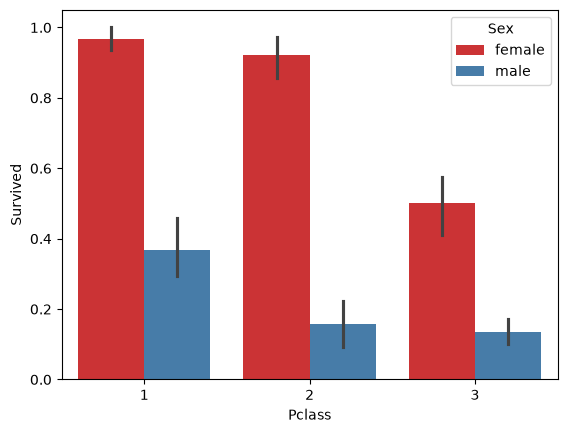

In [ ]:
#Task 4.3 How is the survival rate of passengers(colored by "Sex") in the different classes ("Pclass")? Make a barplot.
plt.figure(6)
#Your code

sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df_titanic, palette="Set1")

"""
Write your answer to the question here.

According for the barplot, both class and sex have a strong correlation with survival rates. Females in all classes have a higher survival
rates compared to their male counterparts. Class 1 has the highest survival rates for both sexes, followed by Class 2 and then Class 3.
Females in Class 1 and 2 have similar amounts of survival rates, while males in class 2 and 3 have similar survival rates.

"""


<div class="alert alert-block alert-warning">

## Task 5


Survival seems to be correlated with the passenger class. Looking at the plot of Task 4.3, something is unusual about the survival rate of female passengers in the third class. But first, lets look at the survival rate of children, passengers under the age of 14.

* 5.1 Plot Pclass vs Survived using a <strong>barplot()</strong> for passengers under the age of 14. Color by "Sex". What do you see?
* 5.2 Plot Pclass vs Survived using a <strong>barplot()</strong> for passengers abover or equal the age of 14. Color by "Sex". What do you see?
* 5.3 Plot number of male and female children in each class using <strong>countplot()</strong>.
* 5.4 Given this three points of information, did "Women and children first" also apply to the third class? If so, why do you think female passengers (all ages) hat a much lower survival rate then in other classes? Hint: Think about the number of available life boats and where are the lower class decks located?

</div>

'\nYour answer to the question here.\nThere were no females under the age of 14 in class 1, in class 2 females under 14 have 100% survival rate, while in Class 3 it goes down\nto a median of ~50%. For males under 14, Class 1 and Class 2 have a survival rate of 50% while Class 3 has a median survival rate of ~35%. \n'

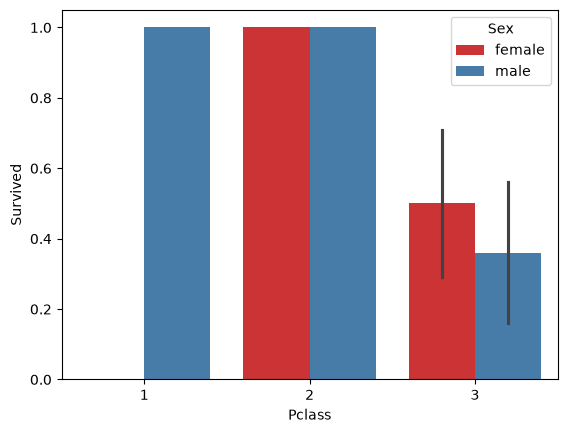

In [ ]:
#Task 5.1 Plot Pclass vs Survived using a <strong>barplot()</strong> for passengers under the age of 14. Color by "Sex". What do you see?

plt.figure(7)
#Your code
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df_titanic[df_titanic["Age"] < 14], palette="Set1")

"""
Your answer to the question here.
There were no females under the age of 14 in class 1, in class 2 females under 14 have 100% survival rate, while in Class 3 it goes down
to a mean of ~50%. For males under 14, Class 1 and Class 2 have a survival rate of 50% while Class 3 has a mean survival rate of ~35%. 
"""

'\nYour answer to the question here.\n\n'

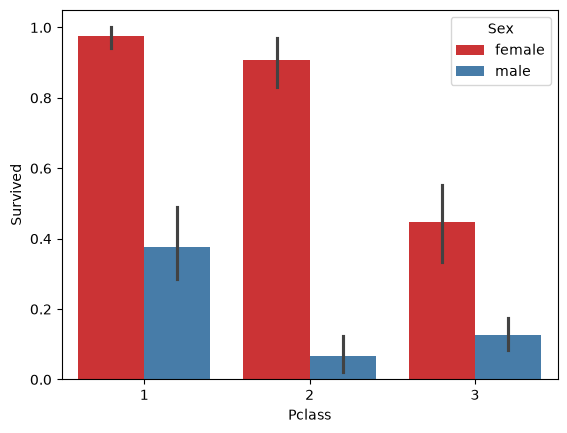

In [ ]:
#Task 5.2 Plot Pclass vs Survived using a <strong>barplot()</strong> for passengers abover or equal the age of 14. Color by "Sex". 
# What do you see?
plt.figure(8)
#Your code

sns.barplot(x="Pclass", y="Survived", hue="Sex", data=df_titanic[df_titanic["Age"] >= 14], palette="Set1")

"""
Your answer to the question here.

For female passengers  he survival rate is higest in Class 1 with ~97% mean, while Class 2 is slighttly under with a mean on ~90%.
Females in Class 3 have a way lower survival rate of ~43%. For male passengers over or equal to 14, Class 1 has a survival rate of ~37%,
while Class 2 has a survival rate of ~8% and Class 3 has a survival rate of ~13%. Meaning there is a strong correlation between both 
class and sex when it comes to survival rates. Especially when it comes to female passenger in Class 1 and 2.

"""

<Axes: xlabel='Pclass', ylabel='count'>

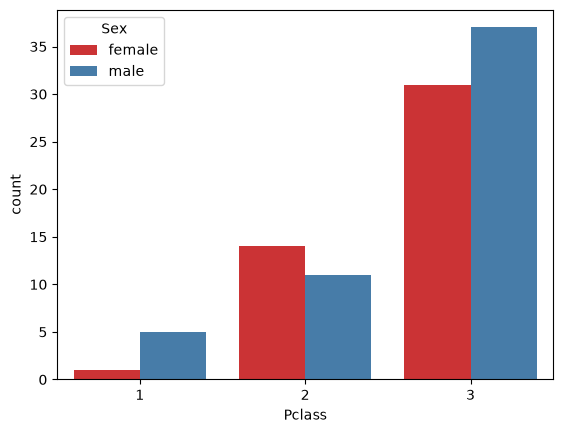

In [67]:
#Task 5.3 Plot number of male and female children in each class using <strong>countplot()</strong>.
plt.figure(9)
#Your code

sns.countplot(x="Pclass", hue="Sex", data=df_titanic[df_titanic["Age"] < 14], palette="Set1")


In [ ]:
#Task 5.4 Given this three points of information, did "Women and children first" also apply to the third class? If so, why do you think 
# female passengers (all ages) hat a much lower survival rate then in other classes? Hint: Think about the number of available life boats 
# and where are the lower class decks located?
"""
Your answer to the question here.

Since the lower classes were located in the lower decks of the ship, it was harder for them to reach the lifeboats. 
The lower classes also had less access to them. Women and children first did apply to the third class, but they either didn't have enough
boats for the Lower class passengers for their population count or they were too far away from the lifeboats to reach them in time.
Leading to a much lower survival rate for female passengers in Class 3 compared to Class 1 and 2.

"""

'\nYour answer to the question here.\n\n\n'

<div class="alert alert-block alert-warning">

## Task 6


Most of the lifeboats where on Deck A. Lets investigate the implication for the survival of the passengers.
As we have seen, most of the cabin data is missing. Nonetheless, lets see if we can still extract some information.

6.1 What percentage of Cabin values missing in each Pclass? Use isnull() and value_counts().

It seems the first class only has about 20% missing values! Lets continue our investigation!

* 6.2 Drop all rows with missing Cabin values. Save the result in the variable <i>df_titanic_nona</i>
    
* 6.3 Extract the first letter of each entry in the Cabin column. Save the result in a new column called "Level" in the <i>df_titanic_nona</i> dataframe.
    
* 6.4 Plot Fare by Level using a <strong>barplot()</strong> of the first class passengers. What is the level with the lowest average fare(ignoring level T)? Does that make sense to you given the location?

6.5 What is the survival rate by level? (Lifeboards were located on deck A (prominade deck)). Anything unusual about the average survival rate of deck A?

6.6 What is the ratio of male to female passengers on each deck? Use a barplot to illustrate. Does it explain the survival rate for deck A?
For this exercise you need to compute the number of female and male passagers on each deck and devide by the total number (female+male) of passengers on that deck. You can then plot the resulting dataframe.



</div>

In [86]:
#Task 6.1  What percentage of Cabin values missing in each Pclass? Use isnull() and value_counts().
# It seems the first class only has about 20% missing values! Lets continue our investigation!

#Your code
# df_titanic.value_counts(subset=["Pclass", "Cabin".isnull()], dropna=False)

df_titanic["Cabin"].isnull().groupby(df_titanic["Pclass"]).value_counts(normalize=True)

Pclass  Cabin
1       False    0.792570
        True     0.207430
2       True     0.916968
        False    0.083032
3       True     0.977433
        False    0.022567
Name: proportion, dtype: float64

In [87]:
#Task 6.2 Drop all rows with missing Cabin values. Save the result in the variable <i>df_titanic_nona</i>

#Your code
df_titanic_nona = df_titanic.dropna(subset=["Cabin"])

In [88]:
#Task 6.3 Extract the first letter of each entry in the Cabin column. Save the result in a new column called "Level" in the 
# <i>df_titanic_nona</i> dataframe.

#Your code
df_titanic_nona["Level"] = df_titanic_nona["Cabin"].str[0]

'\nYour answer to the question here.\nIgnoring T, A seems to be the level with the lowest average fare. It seems like A and T were the worst Levels in Class 1. \n\n'

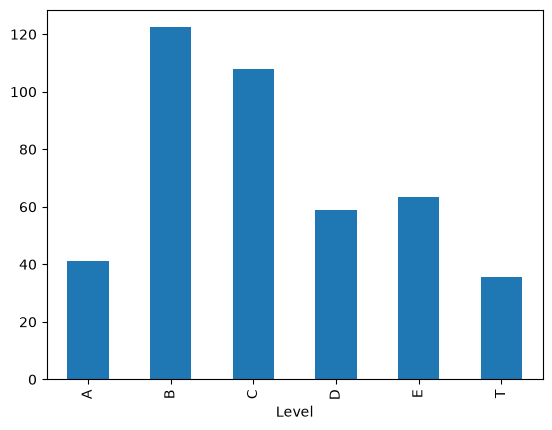

In [89]:
#Task 6.4 Plot Fare by Level using a <strong>barplot()</strong> of the first class passengers. What is the level with the lowest average
# fare(ignoring level T)? Does that make sense to you given the location?

plt.figure(10)
#Your code
df_titanic_nona[df_titanic_nona["Pclass"] == 1].groupby("Level")["Fare"].mean().plot(kind="bar")

"""
Your answer to the question here.
Ignoring T, A seems to be the level with the lowest average fare. It seems like A and T were the worst Levels in Class 1. 

"""

'\nYour answer to the question here.\n\n'

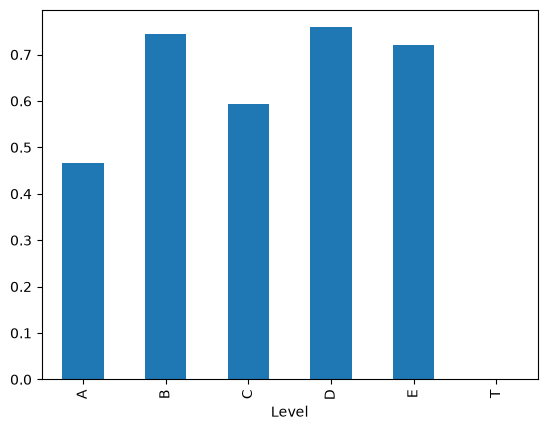

In [ ]:
#Task 6.5 What is the survival rate by level? (Lifeboards were located on deck A (prominade deck)). 
# Anything unusual about the average survival rate of deck A?

plt.figure(11)
#Your code
df_titanic_nona[df_titanic_nona["Pclass"] == 1].groupby("Level")["Survived"].mean().plot(kind="bar")

"""
Your answer to the question here.
The people on deck A has a generally lower survival rate compared to the rest of the group in 
Class 1.

"""

'\nYour answer to the question here.\nIt does somewhat explain it since A was majority Male while G was majority Female.\n\n'

<Figure size 640x480 with 0 Axes>

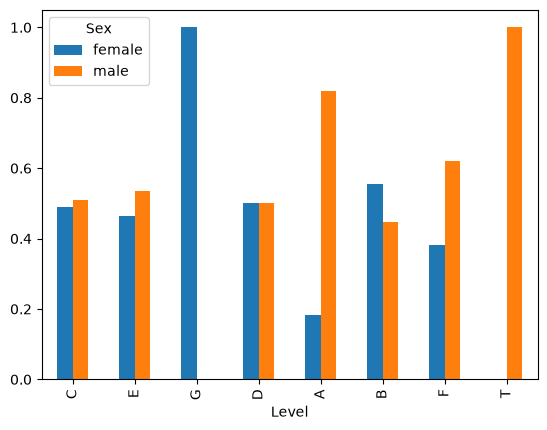

In [103]:
#Task 6.6 What is the ratio of male to female passengers on each deck? Use a barplot to illustrate. 
# Does it explain the survival rate for deck A?
# For this exercise you need to compute the number of female and male passagers on each deck and 
# devide by the total number (female+male) of passengers on that deck. You can then plot the 
# resulting dataframe.

plt.figure(12)
#Your code
ratio = (df_titanic_nona[["Level", "Sex"]].value_counts(sort=True, normalize=False).unstack(fill_value=0))

ratio = ratio.div(ratio.sum(axis=1), axis=0).plot(kind="bar", stacked=False)

"""
Your answer to the question here.
It does somewhat explain it since A was majority Male while G was majority Female.

"""